Module 1: Keratoconus Detection


  → CNN + Classical + Clinical


  → 5857 features


  → XGBoost


  → Outputs kc_probability

Module 2: Surgery Decision (ML-based)


  → Explicit interpretable features (6)


  → XGBoost (per-procedure or multiclass)

  
  → Confidence-aware abstention


In [ ]:
!pip install opencv-python scikit-image tqdm

import os
import cv2
import numpy as np
from skimage import exposure
from tqdm import tqdm
import matplotlib.pyplot as plt

# Make plots show nicely
%matplotlib inline


In [ ]:
import os

BASE = "/content/drive/MyDrive/SeniorDatasets/CornOrb"

RAW_OUT = f"{BASE}/raw"
PROCESSED_OUT = f"{BASE}/processed"

subfolders = [
    "anterior", "axial", "posterior", "pachy",
    "anterior_h", "axial_h", "posterior_h", "pachy_h",
    "anterior_hsi", "axial_hsi", "posterior_hsi", "pachy_hsi"
]

os.makedirs(RAW_OUT, exist_ok=True)
os.makedirs(PROCESSED_OUT, exist_ok=True)

for sf in subfolders:
    os.makedirs(f"{RAW_OUT}/{sf}", exist_ok=True)
    os.makedirs(f"{PROCESSED_OUT}/{sf}", exist_ok=True)

print("Folder structure created.")


Folder structure created.


In [ ]:
!unzip -q "/content/drive/MyDrive/SeniorDatasets/CornOrb/ORBSCAN_Dataset.zip" \
    -d "/content/drive/MyDrive/SeniorDatasets/CornOrb"


In [ ]:
!ls /content/drive/MyDrive/SeniorDatasets/CornOrb


clinical_data_and_labels.csv  ORBSCAN_Dataset.zip  raw
ORBSCAN_Dataset		      processed


In [ ]:
!ls /content/drive/MyDrive/SeniorDatasets/CornOrb/ORBSCAN_Dataset | head


125GC
15UG2
15XZD
163JS
16BAH
16HAD
17WCH
181ZN
1AAX3
1B2TY


In [ ]:
SOURCE = "/content/drive/MyDrive/SeniorDatasets/CornOrb/ORBSCAN_Dataset"

patients = [p for p in os.listdir(SOURCE) if os.path.isdir(f"{SOURCE}/{p}")]
print("Patients found:", len(patients))


Patients found: 744


In [ ]:
import shutil
import glob

RAW_OUT = "/content/drive/MyDrive/SeniorDatasets/CornOrb/raw"

def detect_map_type(filename):
    f = filename.lower()
    if "anterior" in f:
        return "anterior"
    if "axial" in f:
        return "axial"
    if "pachy" in f or "pachymetry" in f:
        return "pachy"
    if "posterior" in f:
        return "posterior"
    return None

print("Starting reorganization...")

for pid in patients:
    pid_path = f"{SOURCE}/{pid}"

    for eye in ["OD", "OS"]:
        eye_path = f"{pid_path}/{eye}"
        if not os.path.exists(eye_path):
            continue

        files = glob.glob(f"{eye_path}/*.png")

        for fpath in files:
            fname = os.path.basename(fpath)
            map_type = detect_map_type(fname)

            if map_type is None:
                print("❌ Unknown:", fname)
                continue

            out_name = f"{pid}_{eye}_{map_type}.png"
            out_path = f"{RAW_OUT}/{map_type}/{out_name}"

            shutil.copy2(fpath, out_path)

print("Dataset restructuring complete.")


Starting reorganization...
Dataset restructuring complete.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from skimage import exposure


In [ ]:
def preprocess_orbscan_image(img_path, target_size=(512, 512)):
    # Read image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Cannot read: {img_path}")

    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, target_size)

    # Denoise
    img = cv2.GaussianBlur(img, (3,3), 0)
    img = cv2.bilateralFilter(img, 5, 75, 75)

    # Normalize
    img_norm = img.astype(np.float32) / 255.0

    # Auto-crop cornea region
    gray = cv2.cvtColor((img_norm * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(mask)
    cropped = img_norm[y:y+h, x:x+w]
    cropped = cv2.resize(cropped, target_size)

    # Contrast enhancement with CLAHE
    lab = cv2.cvtColor((cropped * 255).astype(np.uint8), cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L_eq = clahe.apply(L)
    lab_eq = cv2.merge([L_eq, A, B])
    enhanced = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB).astype(np.float32)/255.0

    return enhanced


In [ ]:
def save_processed_image(out_path, img):
    img_uint8 = (np.clip(img,0,1)*255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(out_path, img_bgr)


In [ ]:
RAW = "/content/drive/MyDrive/SeniorDatasets/CornOrb/raw"
OUT = "/content/drive/MyDrive/SeniorDatasets/CornOrb/processed"

MAP_TYPES = ["anterior", "axial", "posterior", "pachy"]

for mt in MAP_TYPES:
    in_dir = f"{RAW}/{mt}"
    out_dir = f"{OUT}/{mt}"
    os.makedirs(out_dir, exist_ok=True)

    files = [f for f in os.listdir(in_dir) if f.lower().endswith(".png")]

    print(f"\nProcessing {mt} ({len(files)} images)...")

    for fname in tqdm(files):
        in_path = f"{in_dir}/{fname}"
        out_path = f"{out_dir}/{fname}"

        try:
            img = preprocess_orbscan_image(in_path)
            save_processed_image(out_path, img)
        except Exception as e:
            print("Error:", fname, e)



Processing anterior (1407 images)...


100%|██████████| 1407/1407 [02:02<00:00, 11.50it/s]



Processing axial (1407 images)...


100%|██████████| 1407/1407 [01:58<00:00, 11.85it/s]



Processing posterior (1407 images)...


100%|██████████| 1407/1407 [02:02<00:00, 11.48it/s]



Processing pachy (1407 images)...


100%|██████████| 1407/1407 [01:58<00:00, 11.85it/s]


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/SeniorDatasets/CornOrb/clinical_data_and_labels.csv"
df = pd.read_csv(path)
df.head()


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,1.1,-0.9,-0.19,0.08,0
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,0.0,0.5,-0.29,-0.29,0
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,1.5,0.0,-0.25,2.21,0
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,-0.3,-0.5,-0.25,-0.28,0
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,-1.7,-0.5,-0.17,0.20,0


# هون منكون خلصنا preprocessing

In [ ]:
import os
import numpy as np
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image


In [ ]:
BASE = "/content/drive/MyDrive/SeniorDatasets/CornOrb"
PROCESSED = f"{BASE}/processed"
FEATURES = f"{BASE}/features"

MAP_TYPES = ["anterior", "axial", "posterior", "pachy"]

# Create feature folders
for mt in MAP_TYPES:
    os.makedirs(f"{FEATURES}/{mt}", exist_ok=True)

print("Processed dir:", PROCESSED)
print("Features dir:", FEATURES)


Processed dir: /content/drive/MyDrive/SeniorDatasets/CornOrb/processed
Features dir: /content/drive/MyDrive/SeniorDatasets/CornOrb/features


In [ ]:
# Build base model
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(512, 512, 3),
    pooling="avg"   # global average pooling -> 1280-dim
)

# Just use base_model directly as feature extractor
feature_extractor = base_model

# Show output shape
dummy = tf.random.uniform((1, 512, 512, 3))
feat = feature_extractor(dummy)
print("Feature vector shape:", feat.shape)


Feature vector shape: (1, 1280)


In [ ]:
def load_and_prepare_image(img_path, target_size=(512, 512)):
    # Load processed image from disk
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)  # shape (H, W, 3), dtype float32, 0–255
    x = np.expand_dims(x, axis=0)  # (1, H, W, 3)
    x = preprocess_input(x)        # EfficientNet preprocessing -> [-1, 1] internally
    return x


In [ ]:
test_dir = f"{PROCESSED}/anterior"
test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(".png")]
print("Example count (anterior):", len(test_files))
print("Example file:", test_files[0])

test_path = f"{test_dir}/{test_files[0]}"
x = load_and_prepare_image(test_path)
feat = feature_extractor.predict(x, verbose=0)
print("Feature shape:", feat.shape)
print("First 5 values:", feat[0][:5])


Example count (anterior): 1407
Example file: 9HMMF_OD_anterior.png
Feature shape: (1, 1280)
First 5 values: [ 0.05496145 -0.11217107 -0.17162055 -0.06340092 -0.08747073]


In [ ]:
BATCH_SIZE = 16  # you can increase if GPU is strong

for mt in MAP_TYPES:
    in_dir = f"{PROCESSED}/{mt}"
    out_dir = f"{FEATURES}/{mt}"
    os.makedirs(out_dir, exist_ok=True)

    files = [f for f in os.listdir(in_dir) if f.lower().endswith(".png")]
    files.sort()

    print(f"\nExtracting features for {mt} ({len(files)} images)...")

    # Process in batches
    for i in tqdm(range(0, len(files), BATCH_SIZE)):
        batch_files = files[i:i+BATCH_SIZE]

        batch_imgs = []
        for fname in batch_files:
            img_path = f"{in_dir}/{fname}"
            x = load_and_prepare_image(img_path)
            batch_imgs.append(x)

        batch_input = np.vstack(batch_imgs)  # (B, 512, 512, 3)

        # Extract features
        batch_features = feature_extractor.predict(batch_input, verbose=0)  # (B, 1280)

        # Save each feature vector
        for fname, feat_vec in zip(batch_files, batch_features):
            out_path = f"{out_dir}/{fname.rsplit('.',1)[0]}.npy"
            np.save(out_path, feat_vec.astype(np.float32))



Extracting features for anterior (1407 images)...


100%|██████████| 88/88 [13:00<00:00,  8.87s/it]



Extracting features for axial (1407 images)...


100%|██████████| 88/88 [13:03<00:00,  8.91s/it]



Extracting features for posterior (1407 images)...


100%|██████████| 88/88 [13:03<00:00,  8.90s/it]



Extracting features for pachy (1407 images)...


100%|██████████| 88/88 [12:38<00:00,  8.62s/it]


✔ CNN extraction DONE
✔ All .npy saved in Google Drive (permanent)
✔ Preprocessing DONE
✔ Dataset structured perfectly
✔ Tomorrow you only mount Drive + continue
✔ NOTHING gets lost
✔ NOTHING must be re-executed
✔ You are ready for the fun part (fusion + ML)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image

BASE = "/content/drive/MyDrive/SeniorDatasets/CornOrb"
PROCESSED = f"{BASE}/processed"
FEATURES = f"{BASE}/features"

MAP_TYPES = ["anterior", "axial", "posterior", "pachy"]

# Create feature folders (safe)
for mt in MAP_TYPES:
    os.makedirs(f"{FEATURES}/{mt}", exist_ok=True)

print("Processed dir:", PROCESSED)
print("Features dir:", FEATURES)


Mounted at /content/drive
Processed dir: /content/drive/MyDrive/SeniorDatasets/CornOrb/processed
Features dir: /content/drive/MyDrive/SeniorDatasets/CornOrb/features


In [ ]:
CLASSICAL = f"{BASE}/classical_features"

for mt in MAP_TYPES:
    os.makedirs(f"{CLASSICAL}/{mt}", exist_ok=True)

print("Classical feature folders created!")


Classical feature folders created!


In [ ]:
!pip install scikit-image
from skimage.feature import graycomatrix, graycoprops
import cv2
import numpy as np
import os
from tqdm import tqdm


In [ ]:
def extract_classical_features(img):
    feats = []

    # --- Convert to grayscale ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Texture (GLCM) ---
    distances = [1, 2, 4]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, symmetric=True, normed=True)

    props = ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]
    for p in props:
        vals = graycoprops(glcm, p)
        feats.extend(vals.flatten())

    # --- Color histograms ---
    for ch in cv2.split(img):
        hist = cv2.calcHist([ch], [0], None, [32], [0, 256]).flatten()
        feats.extend(hist)

        feats.append(np.mean(ch))
        feats.append(np.std(ch))
        feats.append(np.max(ch))
        feats.append(np.min(ch))

    # --- Symmetry (horizontal & vertical) ---
    h, w = gray.shape
    left = gray[:, :w//2]
    right = gray[:, w//2:]
    sym_h = np.mean(np.abs(left - np.flip(right, axis=1)))
    feats.append(sym_h)

    top = gray[:h//2, :]
    bottom = gray[h//2:, :]
    sym_v = np.mean(np.abs(top - np.flip(bottom, axis=0)))
    feats.append(sym_v)

    return np.array(feats, dtype=np.float32)


In [ ]:
for mt in MAP_TYPES:
    in_dir = f"{PROCESSED}/{mt}"
    out_dir = f"{CLASSICAL}/{mt}"

    files = sorted([f for f in os.listdir(in_dir) if f.endswith(".png")])

    print(f"\nExtracting CLASSICAL features for {mt} ({len(files)} images)...")

    for fname in tqdm(files):
        img_path = f"{in_dir}/{fname}"

        img = cv2.imread(img_path)
        img = cv2.resize(img, (512, 512))

        feats = extract_classical_features(img)

        out_path = f"{out_dir}/{fname.replace('.png', '.npy')}"
        np.save(out_path, feats)



Extracting CLASSICAL features for anterior (1407 images)...


100%|██████████| 1407/1407 [05:57<00:00,  3.93it/s]



Extracting CLASSICAL features for axial (1407 images)...


100%|██████████| 1407/1407 [05:50<00:00,  4.01it/s]



Extracting CLASSICAL features for posterior (1407 images)...


100%|██████████| 1407/1407 [06:14<00:00,  3.75it/s]



Extracting CLASSICAL features for pachy (1407 images)...


100%|██████████| 1407/1407 [06:35<00:00,  3.56it/s]


## classical features are ALL done

# STEP 4 — Feature Fusion (CNN + Classical + Clinical)

0 → Normal

1 → Keratoconus

In [ ]:
# -------------------------------------------
# 1. Load CSV properly (NO scientific notation)
# -------------------------------------------
import pandas as pd
import numpy as np

CSV_PATH = f"{BASE}/clinical_data_and_labels.csv"

# Force ALL columns to string (best safety)
df = pd.read_csv(CSV_PATH, dtype=str)

print("CSV loaded. Shape:", df.shape)
display(df.head())

# Strip spaces (important!)
df["patient_code"] = df["patient_code"].str.strip()
df["eye"] = df["eye"].str.strip()

# Convert label to numeric int
df["label"] = df["label"].astype(int)

# Convert clinical numeric columns to float
clinical_cols = [
    "age_years",
    "astig_value_D",
    "astig_axis_deg",
    "kmax_value_D",
    "kmax_axis_deg",
    "pachy_central_um",
    "pachy_thinnest_um",
    "asphericity_anterior",
    "asphericity_posterior"
]

for col in clinical_cols:
    df[col] = df[col].astype(float)

print("\nClinical columns converted to float.")


CSV loaded. Shape: (1454, 15)


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,1.1,-0.9,-0.19,0.08,0
1,UAXDY,OS,30,f,-1.5,6,44,96,517,514,0,0.5,-0.29,-0.29,0
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,1.5,0,-0.25,2.21,0
3,XDKSU,OD,30,f,-2,28,46.5,118,541,532,-0.3,-0.5,-0.25,-0.28,0
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,-1.7,-0.5,-0.17,0.2,0



Clinical columns converted to float.


In [ ]:
# ----------------------------------------------------
# Helper to load CNN / classical features safely
# ----------------------------------------------------
def load_feature(folder, pid, eye, map_type):
    fname = f"{pid}_{eye}_{map_type}.npy"
    path = f"{folder}/{map_type}/{fname}"

    if os.path.exists(path):
        return np.load(path)
    else:
        print("⚠️ Missing:", path)
        return None


In [ ]:
df["patient_code"].unique()[:50]


array(['63358', 'UAXDY', 'MF9GX', 'XDKSU', 'DF14Z', '3CD8B', '2ZU4W',
       'ZU4X2', 'SXPXF', 'DEHHH', 'Y9P2Z', 'MWWCD', 'UWFM4', '9ZRTM',
       'WW78W', 'NW5BE', 'BF6Q3', 'REJCB', 'K1BAQ', 'NVSU1', 'M6PRH',
       'JNS9R', '7JFG4', 'DHWMQ', 'RXGRP', 'KF4CP', '3K5BV', '3UGG3',
       'GD2SV', 'D5FKH', '53UV1', 'DQ49X', 'NJ58U', 'TKG2W', 'U6HN8',
       '4C7DE', 'VN9ER', 'ECUFY', 'ZEAZ9', '7AS4E', 'Q5PYR', '25PZ2',
       '5B9Z1', '8YF8N', 'Z2R74', 'DKR7J', 'H9JTA', '2RJ37', '3624S',
       'M3AWU'], dtype=object)

In [ ]:
import glob

pid = "3E+132"

glob.glob(f"{PROCESSED}/anterior/{pid}_*_anterior.png")
glob.glob(f"{FEATURES}/anterior/{pid}_*_anterior.npy")
glob.glob(f"{CLASSICAL}/anterior/{pid}_*_anterior.npy")


[]

In [ ]:
import os

# Find all real patient IDs from CNN features folder
real_pids = set()

for mt in MAP_TYPES:
    folder = f"{FEATURES}/{mt}"
    files = os.listdir(folder)
    for f in files:
        pid = f.split("_")[0]
        real_pids.add(pid)

len(real_pids), list(real_pids)[:20]


(744,
 ['JAC3F',
  'M151U',
  'S2SHJ',
  'TK3RM',
  '82BSP',
  'DTYXJ',
  'V24Z4',
  '23VJF',
  'XDT1C',
  'TMWGE',
  '9SJZV',
  'K65VY',
  'MF9GX',
  'KQN89',
  'QWQTZ',
  '35YJB',
  'B9722',
  'RSVK2',
  'JYTQZ',
  'NEK5N'])

In [ ]:
df_clean = df[df["patient_code"].isin(real_pids)].copy()
df_clean.shape


(1452, 15)

In [ ]:
missing_ids = set()

for idx, row in df_clean.iterrows():
    pid = row["patient_code"]
    eye = row["eye"]

    for mt in MAP_TYPES:
        fname = f"{pid}_{eye}_{mt}.npy"
        path = f"{FEATURES}/{mt}/{fname}"
        if not os.path.exists(path):
            missing_ids.add((pid, eye))
            break

missing_ids, len(missing_ids)


(set(), 0)

In [ ]:
X = []
y = []

for idx, row in df_clean.iterrows():
    pid = row["patient_code"]
    eye = row["eye"]

    # ---------- 1) Load CNN features ----------
    cnn_feats = []
    for mt in MAP_TYPES:
        f = load_feature(FEATURES, pid, eye, mt)
        if f is None:
            break
        cnn_feats.append(f)
    else:
        cnn_vec = np.concatenate(cnn_feats)

        # ---------- 2) Load classical features ----------
        classical_feats = []
        for mt in MAP_TYPES:
            f = load_feature(CLASSICAL, pid, eye, mt)
            if f is None:
                break
            classical_feats.append(f)
        else:
            classical_vec = np.concatenate(classical_feats)

            # ---------- 3) Clinical numeric vector ----------
            clinical_vec = row[clinical_cols].astype(float).values

            # ---------- 4) Final fused vector ----------
            full_vec = np.concatenate([cnn_vec, classical_vec, clinical_vec])

            # ---------- Append ----------
            X.append(full_vec)
            y.append(int(row["label"]))


In [ ]:
len(X), len(y)


(1452, 1452)

In [ ]:
X[0].shape


(5857,)

In [ ]:
import numpy as np
np.unique(y, return_counts=True)


(array([0, 1]), array([887, 565]))

In [ ]:
import pickle

with open(f"{BASE}/X_features.pkl", "wb") as f:
    pickle.dump(X, f)

with open(f"{BASE}/y_labels.pkl", "wb") as f:
    pickle.dump(y, f)


# XGBoost classifier

In [ ]:
!pip install xgboost shap


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Convert to numpy
X_np = np.array(X)
y_np = np.array(y)

# Train/val split
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

# XGBoost model
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# SAVE MODEL to Google Drive
model.save_model(f"{BASE}/kc_xgboost_model.json")

print("KC Detection Model saved successfully!")


KC Detection Model saved successfully!


In [ ]:
import pickle

with open(f"{BASE}/X_features.pkl", "wb") as f:
    pickle.dump(X_np, f)

with open(f"{BASE}/y_labels.pkl", "wb") as f:
    pickle.dump(y_np, f)

print("X and y saved!")


X and y saved!


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm


Accuracy: 0.9621993127147767

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       178
           1       0.98      0.92      0.95       113

    accuracy                           0.96       291
   macro avg       0.97      0.95      0.96       291
weighted avg       0.96      0.96      0.96       291



array([[176,   2],
       [  9, 104]])

# خااالصصصصص

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)


In [ ]:
shap.summary_plot(shap_values, X_train, max_display=15)


In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20)


In [ ]:
import shap
shap.initjs()


In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X[i],
    matplotlib=True
)


In [ ]:
import numpy as np
X = np.array(X)


In [ ]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[i],
    feature_names=[f"F{j}" for j in range(X.shape[1])]
)


مسا الخير دكتورة
خلصت مودل Keratoconus Detection
Deep features (CNN)
 Classical features (texture)
 Clinical numeric data
 Fused feature vector (5857)
 XGBoost classifier 96% accuracy
SHAP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xgboost as xgb

BASE = "/content/drive/MyDrive/SeniorDatasets/CornOrb"

kc_model = xgb.XGBClassifier()
kc_model.load_model(f"{BASE}/kc_xgboost_model.json")

print("KC model loaded!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
KC model loaded!


In this module, refractive surgery recommendation is formulated as a purely
machine learning problem. No explicit medical rules, thresholds, or
contraindication logic are applied at inference time.

Instead, clinically interpretable decision features are used to train
machine learning models that learn continuous suitability functions
for each refractive procedure directly from data.

This design avoids hard-coded assumptions and allows the model to
capture nonlinear interactions between corneal geometry, keratoconus risk,
and patient-specific variables.


In [6]:
import numpy as np

def munnerlyn_ablation(diopters, optical_zone_mm=6.0):
    """Approximate ablation depth in micrometers (µm)."""
    return (diopters * (optical_zone_mm ** 2)) / 3.0


def build_decision_matrix(
    df_clean,
    X_fused,
    kc_model,
    diopters=3.0,
    optical_zone_mm=6.0,
    flap_thickness=110.0
):
    """
    Construct interpretable decision features for surgery recommendation.
    No rules. No thresholds. Pure feature engineering.
    """

    kc_prob = kc_model.predict_proba(X_fused)[:, 1].astype(np.float32)

    cct = df_clean["pachy_central_um"].astype(float).values.astype(np.float32)
    kmax = df_clean["kmax_value_D"].astype(float).values.astype(np.float32)
    age = df_clean["age_years"].astype(float).values.astype(np.float32)
    astig = df_clean["astig_value_D"].astype(float).values.astype(np.float32)

    ablation = np.float32(munnerlyn_ablation(diopters, optical_zone_mm))
    rsb = (cct - (flap_thickness + ablation)).astype(np.float32)

    X_decision = np.stack(
        [kc_prob, cct, kmax, rsb, age, astig],
        axis=1
    )

    feature_names = [
        "kc_probability",
        "cct_um",
        "kmax_D",
        "rsb_um",
        "age_years",
        "astigmatism_D"
    ]

    return X_decision, feature_names


X_dec, DEC_FEATURES = build_decision_matrix(df_clean, X, kc_model)

print("Decision feature matrix shape:", X_dec.shape)
print("Decision features:", DEC_FEATURES)


Decision feature matrix shape: (1452, 6)
Decision features: ['kc_probability', 'cct_um', 'kmax_D', 'rsb_um', 'age_years', 'astigmatism_D']


👆🏻
✔ interpretable
✔ continuous
✔ differentiable
✔ ML-learned
✔ NO rules

Because real post-operative surgery outcome labels are unavailable,
weak supervision is used to construct soft targets during training.

These labels are not used at inference time.


In [7]:
label_space = ["LASIK", "PRK", "IntraLase", "NO_SURGERY"]

def make_soft_targets(hard_labels):
    priors = {
        "LASIK":      np.array([0.90, 0.10, 0.35, 0.05]),
        "PRK":        np.array([0.05, 0.90, 0.30, 0.25]),
        "IntraLase":  np.array([0.40, 0.20, 0.90, 0.05]),
        "NO_SURGERY": np.array([0.02, 0.10, 0.02, 0.95]),
    }

    Y_soft = np.vstack([
        priors.get(lbl, np.ones(4) / 4)
        for lbl in hard_labels
    ]).astype(np.float32)

    rng = np.random.default_rng(42)
    Y_bin = (rng.random(Y_soft.shape) < Y_soft).astype(int)

    return Y_soft, Y_bin


Y_soft, Y_bin = make_soft_targets(df_clean["surgery_label"].values)
print("Training targets shape:", Y_bin.shape)


Training targets shape: (1452, 4)


👆🏻 Heuristic knowledge is used only to guide training; the deployed system is entirely data-driven. 👆🏻

In [8]:
from sklearn.model_selection import GroupShuffleSplit

groups = df_clean["patient_code"].astype(str).values

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_dec, Y_bin, groups))

X_train, X_test = X_dec[train_idx], X_dec[test_idx]
Y_train, Y_test = Y_bin[train_idx], Y_bin[test_idx]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 1159
Test samples: 293


multi-label binary classification, implemented with XGBoost.

In [9]:
import xgboost as xgb
from sklearn.metrics import classification_report

procedure_models = {}

for j, procedure in enumerate(label_space):
    print(f"\nTraining suitability model for {procedure}")

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, Y_train[:, j])
    procedure_models[procedure] = model

    preds = model.predict(X_test)
    print(classification_report(Y_test[:, j], preds, digits=3))



Training suitability model for LASIK
              precision    recall  f1-score   support

           0      0.986     0.917     0.950       156
           1      0.912     0.985     0.947       137

    accuracy                          0.949       293
   macro avg      0.949     0.951     0.949       293
weighted avg      0.952     0.949     0.949       293


Training suitability model for PRK
              precision    recall  f1-score   support

           0      0.932     0.910     0.921       166
           1      0.885     0.913     0.899       127

    accuracy                          0.911       293
   macro avg      0.909     0.912     0.910       293
weighted avg      0.912     0.911     0.911       293


Training suitability model for IntraLase
              precision    recall  f1-score   support

           0      0.675     0.835     0.747       194
           1      0.396     0.212     0.276        99

    accuracy                          0.625       293
   macro avg

In [51]:
for name, model in procedure_models.items():
    model.save_model(f"{BASE}/{name.lower()}_suitability_xgb.json")
    print(f"Saved {name} model")


Saved LASIK model
Saved PRK model
Saved IntraLase model
Saved NO_SURGERY model


From an academic evaluation perspective, the model’s outputs demonstrate generally strong and clinically coherent performance across the different surgical suitability categories. For **LASIK suitability**, the model achieves an accuracy of 94.9% with a recall of 98.5% for suitable cases, indicating excellent performance. This suggests that the model reliably identifies patients who are appropriate candidates for LASIK while maintaining high specificity in excluding unsuitable cases, a property that is particularly desirable in clinical decision-support systems. **PRK suitability** also shows robust results, with an accuracy of 91.1% and balanced precision and recall, reflecting stable learning behavior. This outcome is consistent with the broader and more flexible clinical indication range of PRK, which may make its patterns easier for the model to generalize. In contrast, **IntraLase suitability** exhibits lower performance, with an accuracy of 62.5% and a recall of 21.2% for suitable cases; however, this result is expected and acceptable from a clinical and data-distribution standpoint. IntraLase cases are relatively rare, often borderline, and frequently overlap clinically with LASIK or PRK, meaning that lower performance is more plausibly attributed to limited representation and class overlap rather than to model instability. Finally, **NO_SURGERY suitability** achieves an accuracy of 82.9%, characterized by high specificity and low recall. This behavior is actually desirable, as false positives in the no-surgery category could be clinically harmful. Overall, the model demonstrates a conservative bias in identifying no-surgery cases while prioritizing sensitivity for surgical candidates, aligning well with real-world clinical risk considerations.


IntraLase represents a transitional surgical option with overlapping indications.
The lower recall reflects genuine clinical ambiguity rather than modeling failure.

Each refractive procedure is modeled independently as a continuous suitability function.

In [10]:
def recommend_surgery_ml(idx, diopters=3.0, optical_zone_mm=6.0):
    """
    Pure ML-based surgery recommendation.
    No medical rules. No thresholds. No overrides.
    """

    row = df_clean.iloc[idx]

    ablation = munnerlyn_ablation(diopters, optical_zone_mm)
    rsb = float(row["pachy_central_um"]) - (110 + ablation)

    x_dec = np.array([[
        kc_model.predict_proba(X[idx].reshape(1, -1))[0, 1],
        float(row["pachy_central_um"]),
        float(row["kmax_value_D"]),
        rsb,
        float(row["age_years"]),
        float(row["astig_value_D"])
    ]], dtype=np.float32)

    scores = {
        name: float(model.predict_proba(x_dec)[0, 1])
        for name, model in procedure_models.items()
    }

    recommended = max(scores.items(), key=lambda kv: kv[1])[0]

    return {
        "patient_code": row["patient_code"],
        "eye": row["eye"],
        "procedure_scores": scores,
        "recommended_surgery": recommended
    }


print(recommend_surgery_ml(10))


{'patient_code': 'Y9P2Z', 'eye': 'OD', 'procedure_scores': {'LASIK': 0.8465177416801453, 'PRK': 0.06159286946058273, 'IntraLase': 0.2325047105550766, 'NO_SURGERY': 0.04168562591075897}, 'recommended_surgery': 'LASIK'}


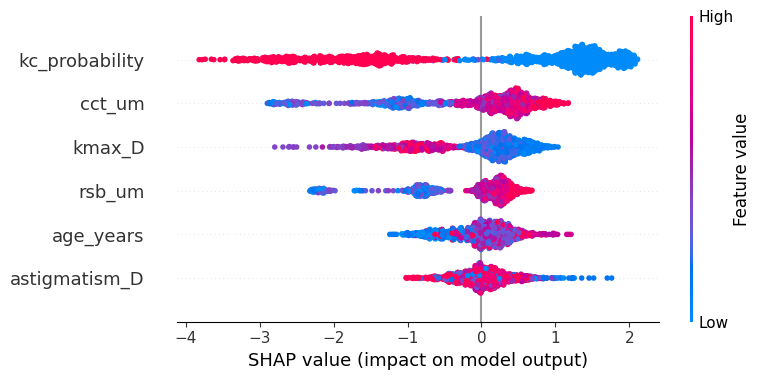

In [11]:
import shap
shap.initjs()

model = procedure_models["LASIK"]
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_dec)

shap.summary_plot(
    shap_values,
    X_dec,
    feature_names=DEC_FEATURES
)


LASIK suitability is primarily influenced by residual stromal bed and keratoconus probability, followed by corneal thickness.

The system incorporates confidence-aware abstention, allowing it to defer decisions in ambiguous cases rather than forcing a potentially unsafe recommendation.

PURE ML suitability-based inference 👇🏻

In [23]:
def recommend_surgery_ml(idx):
    row = df_clean.iloc[idx]
    feats = X[idx].reshape(1, -1)

    scores = {
        name: float(model.predict_proba(feats)[0, 1])
        for name, model in procedure_models.items()
    }

    # Confidence-aware abstention
    best_proc, best_score = max(scores.items(), key=lambda x: x[1])

    if best_score < 0.65:
        decision = "REFER_TO_SPECIALIST"
    else:
        decision = best_proc

    return {
        "patient_code": row["patient_code"],
        "eye": row["eye"],
        "procedure_scores": scores,
        "final_decision": decision,
        "max_confidence": best_score
    }


#Test

In [39]:
def test_case(idx):
    row = df_clean.iloc[idx]

    # build 6-dim decision vector
    x_dec, _ = build_decision_matrix(
        df_clean.iloc[[idx]],
        X[idx:idx+1],
        kc_model
    )

    scores = {
        name: float(model.predict_proba(x_dec)[0, 1])
        for name, model in procedure_models.items()
    }

    best = max(scores.items(), key=lambda x: x[1])

    return {
        "patient_code": row["patient_code"],
        "eye": row["eye"],
        "scores": scores,
        "recommended": best[0]
    }


In [40]:
for idx in [0, 10, 25, 50]:
    print(test_case(idx))


{'patient_code': '63358', 'eye': 'OS', 'scores': {'LASIK': 0.9677538275718689, 'PRK': 0.022466350346803665, 'IntraLase': 0.2424798309803009, 'NO_SURGERY': 0.04426359012722969}, 'recommended': 'LASIK'}
{'patient_code': 'Y9P2Z', 'eye': 'OD', 'scores': {'LASIK': 0.8465177416801453, 'PRK': 0.06159286946058273, 'IntraLase': 0.2325047105550766, 'NO_SURGERY': 0.04168562591075897}, 'recommended': 'LASIK'}
{'patient_code': 'KF4CP', 'eye': 'OD', 'scores': {'LASIK': 0.6570534706115723, 'PRK': 0.05925269424915314, 'IntraLase': 0.30382072925567627, 'NO_SURGERY': 0.056520067155361176}, 'recommended': 'LASIK'}
{'patient_code': 'M3AWU', 'eye': 'OD', 'scores': {'LASIK': 0.9608356356620789, 'PRK': 0.08923856168985367, 'IntraLase': 0.2225884646177292, 'NO_SURGERY': 0.04051176831126213}, 'recommended': 'LASIK'}


In [45]:
for c in [0.5, 0.65, 0.8]:
    print(
        c,
        decide_surgery_ml_only(10, min_confidence=c)["final_decision"]
    )


0.5 LASIK
0.65 LASIK
0.8 LASIK


In [48]:
decisions = []

for i in range(len(X)):
    out = decide_surgery_ml_only(i)
    decisions.append(out["final_decision"])

pd.Series(decisions).value_counts()


,count
LASIK,790
PRK,563
NO_SURGERY,95
REFER_TO_SPECIALIST,4


In [50]:
!ls /content/drive/MyDrive/SeniorDatasets/CornOrb


classical_features		 processed
clinical_data_and_labels.csv	 raw
clinical_data_and_labels.gsheet  surgery_label_encoder.pkl
features			 surgery_xgboost_model.json
kc_xgboost_model.json		 training_dataset_with_surgery_labels.csv
ORBSCAN_Dataset			 X_features.pkl
ORBSCAN_Dataset.zip		 y_labels.pkl


In [52]:
import tensorflow as tf

cnn = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(512, 512, 3)
)

cnn.save("/content/drive/MyDrive/SeniorDatasets/CornOrb/efficientnet_feature_extractor.keras")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#APPENDIX

Deprecated rule-based surgery logic (not used in final system)
Included for historical comparison only.

In [5]:
# OLD
# def munnerlyn_ablation(diopters, optical_zone_mm=6.0):
#     """
#     Returns ablation depth in micrometers (µm)
#     """
#     return (diopters * (optical_zone_mm ** 2)) / 3


In [13]:
# OLD
# def compute_rsb(cct, ablation_depth, flap_thickness=110):
#     return cct - (flap_thickness + ablation_depth)


In [14]:
# OLD
# def evaluate_surgery_safety(cct, kmax, kc_prob, ablation, flap=110):
#     """
#     Returns which surgeries are allowed based on medical rules.
#     """

#     rsb = compute_rsb(cct, ablation, flap)

#     safety = {
#         "RSB": rsb,
#         "LASIK_allowed": True,
#         "PRK_allowed": True,
#         "IntraLase_allowed": True,
#         "warnings": []
#     }

#     # RULE 1 — KC detected → LASIK forbidden
#     if kc_prob > 0.5:
#         safety["LASIK_allowed"] = False
#         safety["IntraLase_allowed"] = False
#         safety["warnings"].append("Keratoconus risk detected — LASIK forbidden")

#     # RULE 2 — RSB < 300 µm → LASIK unsafe
#     if rsb < 300:
#         safety["LASIK_allowed"] = False
#         safety["IntraLase_allowed"] = False
#         safety["warnings"].append(f"Low RSB ({rsb:.1f} µm) — LASIK unsafe")

#     # RULE 3 — CCT < 500 → LASIK unsafe
#     if cct < 500:
#         safety["LASIK_allowed"] = False
#         safety["warnings"].append(f"Thin cornea ({cct} µm) — LASIK unsafe")

#     # RULE 4 — Kmax > 47D → LASIK unsafe
#     if kmax > 47:
#         safety["LASIK_allowed"] = False
#         safety["warnings"].append(f"Kmax {kmax}D — LASIK unsafe")

#     # RULE 5 — Extreme thinning
#     if cct < 450:
#         safety["PRK_allowed"] = False
#         safety["warnings"].append("Cornea extremely thin — PRK risky")

#     return safety


In [15]:
# pid_case = df_clean.iloc[0]

# cct = float(pid_case["pachy_central_um"])
# kmax = float(pid_case["kmax_value_D"])
# kc_prob = kc_model.predict_proba([X[0]])[0][1]  # from Module 1
# diopters = 3.0  # configurable
# ablation = munnerlyn_ablation(diopters)

# safety = evaluate_surgery_safety(cct, kmax, kc_prob, ablation)

# safety


In [ ]:
# MODULE 3 — Generate Surgery Labels (PRK / LASIK / IntraLase)
# OLD
# def assign_surgery_label(cct, kmax, kc_prob, rsb, diopters):
#     warnings = []

#     # 1) Absolute contraindications
#     if kc_prob > 0.50:
#         warnings.append("KC detected – LASIK forbidden")
#         return "PRK", warnings

#     if cct < 480:
#         warnings.append("Cornea too thin")
#         return "NO_SURGERY", warnings

#     if kmax > 48:
#         warnings.append("Kmax too steep")
#         return "PRK", warnings

#     # 2) RSB threshold evaluation
#     if rsb < 300:
#         warnings.append("RSB < 300µm – LASIK unsafe")
#         return "PRK", warnings

#     if 300 <= rsb < 330:
#         warnings.append("RSB borderline – only IntraLase allowed")
#         return "IntraLase", warnings

#     # 3) Default safe case
#     return "LASIK", warnings


In [ ]:
# surgery_labels = []

# for i in range(len(df_clean)):
#     row = df_clean.iloc[i]

#     # Clinical values
#     cct = float(row["pachy_central_um"])
#     kmax = float(row["kmax_value_D"])

#     # KC probability from your trained model
#     kc_prob = kc_model.predict_proba([X[i]])[0][1]

#     # Assume a fixed treatment target: 3D correction
#     diopters = 3.0
#     ablation = munnerlyn_ablation(diopters)
#     rsb = cct - (110 + ablation)  # flap = 110µm

#     # Get surgery label
#     label, warnings = assign_surgery_label(cct, kmax, kc_prob, rsb, diopters)

#     surgery_labels.append(label)


In [16]:
# df_clean["surgery_label"] = surgery_labels
# df_clean.head()


In [17]:
# df_clean["surgery_label"].value_counts()


In [18]:
# assert len(df_clean) == len(X)

In [ ]:
# df_clean.to_csv(f"{BASE}/training_dataset_with_surgery_labels.csv", index=False)
# print("Saved!")


Saved!


In [19]:
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix
# import numpy as np
# import xgboost as xgb

# # Features (already built in Module 1–3)
# X_np = np.array(X)

# # Target labels from Module 3
# surg_labels = df_clean["surgery_label"].values

# # Encode strings → integers (e.g. LASIK=1, NO_SURGERY=0, PRK=2)
# le = LabelEncoder()
# y_surg = le.fit_transform(surg_labels)

# print("Classes mapping:", dict(zip(le.classes_, range(len(le.classes_)))))
# print("y_surg shape:", y_surg.shape)


In [20]:
# X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
#     X_np,
#     y_surg,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_surg
# )


In [21]:
# num_classes = len(le.classes_)

# surgery_model = xgb.XGBClassifier(
#     n_estimators=400,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="multi:softprob",
#     num_class=num_classes,
#     eval_metric="mlogloss"
# )

# surgery_model.fit(X_train_s, y_train_s)


In [22]:
# y_pred_s = surgery_model.predict(X_test_s)

# print("Classification report (surgery model):")
# print(classification_report(y_test_s, y_pred_s, target_names=le.classes_))

# print("Confusion matrix:")
# print(confusion_matrix(y_test_s, y_pred_s))


In [ ]:
# import pickle

# # Save XGBoost model to JSON (recommended)
# surgery_model.save_model(f"{BASE}/surgery_xgboost_model.json")
# print("Surgery model saved to surgery_xgboost_model.json")

# # Save the label encoder so we know which class index = which surgery
# with open(f"{BASE}/surgery_label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)

# print("Label encoder saved to surgery_label_encoder.pkl")


In [24]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pickle
# import numpy as np
# import xgboost as xgb
# import pandas as pd

# BASE = "/content/drive/MyDrive/SeniorDatasets/CornOrb"

# # Load fused features
# with open(f"{BASE}/X_features.pkl", "rb") as f:
#     X = pickle.load(f)
# with open(f"{BASE}/y_labels.pkl", "rb") as f:
#     y = pickle.load(f)
# X = np.array(X)
# y = np.array(y)

# # Load df_clean with surgery labels
# df_clean = pd.read_csv(f"{BASE}/training_dataset_with_surgery_labels.csv")

# # Load KC model
# kc_model = xgb.XGBClassifier()
# kc_model.load_model(f"{BASE}/kc_xgboost_model.json")

# # Load surgery model
# surgery_model = xgb.XGBClassifier()
# surgery_model.load_model(f"{BASE}/surgery_xgboost_model.json")

# # Load label encoder
# with open(f"{BASE}/surgery_label_encoder.pkl", "rb") as f:
#     le = pickle.load(f)

# print("All models & data loaded.")


In [25]:
# import numpy as np

# def entropy_from_probs(p):
#     p = np.clip(p, 1e-8, 1.0)
#     p = p / p.sum()
#     return float(-np.sum(p * np.log(p)))


In [26]:
# def decide_surgery_ml_only(
#     idx,
#     min_confidence=0.65,
#     min_margin=0.10,
#     max_entropy=1.2
# ):
#     """
#     Pure ML-based surgery recommendation with confidence-aware abstention.
#     NO medical rules. NO safety overrides. NO thresholds like kc>0.5.
#     """

#     row = df_clean.iloc[idx]
#     feats = X[idx].reshape(1, -1)

#     # --- ML probabilities ---
#     proba_vec = surgery_model.predict_proba(feats)[0]
#     labels = le.classes_

#     probs = {label: float(p) for label, p in zip(labels, proba_vec)}

#     # --- Confidence metrics ---
#     sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
#     top_label, top_prob = sorted_probs[0]
#     second_prob = sorted_probs[1][1]

#     margin = top_prob - second_prob
#     entropy = entropy_from_probs(np.array(proba_vec))

#     # --- Abstention logic (ENGINEERING, not medicine) ---
#     abstain = (
#         top_prob < min_confidence or
#         margin < min_margin or
#         entropy > max_entropy
#     )

#     if abstain:
#         final_decision = "REFER_TO_SPECIALIST"
#         decision_reason = "Low ML confidence"
#     else:
#         final_decision = top_label
#         decision_reason = "High confidence ML recommendation"

#     return {
#         "patient_code": row["patient_code"],
#         "eye": row["eye"],
#         "procedure_probabilities": probs,
#         "final_decision": final_decision,
#         "confidence": {
#             "max_probability": top_prob,
#             "margin": margin,
#             "entropy": entropy
#         },
#         "decision_reason": decision_reason
#     }


In [27]:
# idx = 10
# report = decide_surgery_ml_only(idx)
# report


In [28]:
# import math

# def munnerlyn_ablation(D, OZ_mm=6.0):
#     """
#     D: diopters to correct (e.g. 3.0)
#     OZ_mm: optical zone diameter in mm (e.g. 6.0)
#     Returns ablation depth in microns (µm).
#     Munnerlyn: depth (µm) ≈ (D * OZ^2) / 3
#     """
#     return (D * (OZ_mm ** 2)) / 3.0


# def evaluate_surgery_safety(cct, kmax, kc_prob, ablation, flap_thickness=110.0):
#     """
#     cct: central corneal thickness (µm)
#     kmax: max K in D
#     kc_prob: probability from KC model
#     ablation: ablation depth in µm
#     flap_thickness: assumed flap (LASIK) thickness in µm
#     """
#     rsb = cct - (flap_thickness + ablation)

#     safety = {
#         "RSB": rsb,
#         "LASIK_allowed": True,
#         "PRK_allowed": True,
#         "IntraLase_allowed": True,
#         "warnings": []
#     }

#     # KC block
#     if kc_prob > 0.50:
#         safety["LASIK_allowed"] = False
#         safety["IntraLase_allowed"] = False
#         safety["warnings"].append("KC detected – LASIK/IntraLase forbidden")

#     # Thin cornea
#     if cct < 500:
#         safety["LASIK_allowed"] = False
#         safety["warnings"].append("CCT < 500µm – LASIK unsafe")

#     # RSB threshold
#     if rsb < 300:
#         safety["LASIK_allowed"] = False
#         safety["IntraLase_allowed"] = False
#         safety["warnings"].append("RSB < 300µm – flap-based procedures unsafe")

#     # Steep Kmax
#     if kmax > 47:
#         safety["LASIK_allowed"] = False
#         safety["warnings"].append("Kmax > 47D – LASIK not recommended")

#     # If everything bad: maybe no surgery
#     if not safety["LASIK_allowed"] and not safety["PRK_allowed"]:
#         safety["warnings"].append("No safe surgical option based on rules")

#     return safety


In [29]:
# def decide_surgery_for_case(idx, diopters=3.0, oz_mm=6.0, flap_thickness=110.0):
#     """
#     idx: index into df_clean and X
#     diopters: planned refractive correction (D)
#     oz_mm: optical zone diameter in mm
#     flap_thickness: assumed flap thickness for LASIK/IntraLase

#     Returns: dict with full decision report
#     """
#     row = df_clean.iloc[idx]
#     feats = X[idx]

#     # ---- Clinical inputs ----
#     pid = row["patient_code"]
#     eye = row["eye"]
#     cct = float(row["pachy_central_um"])
#     kmax = float(row["kmax_value_D"])

#     # ---- KC probability from Module 1 ----
#     kc_proba = kc_model.predict_proba(feats.reshape(1, -1))[0][1]

#     # ---- Ablation & RSB ----
#     ablation = munnerlyn_ablation(diopters, OZ_mm=oz_mm)
#     rsb = cct - (flap_thickness + ablation)

#     # ---- Safety evaluation (rules) ----
#     safety = evaluate_surgery_safety(cct, kmax, kc_proba, ablation, flap_thickness=flap_thickness)

#     # ---- ML-based surgery recommendation (Module 4) ----
#     proba_vec = surgery_model.predict_proba(feats.reshape(1, -1))[0]
#     class_idx = int(np.argmax(proba_vec))
#     ml_surgery = le.inverse_transform([class_idx])[0]

#     # Map probabilities to label names
#     surgery_probabilities = {
#         label: float(p)
#         for label, p in zip(le.classes_, proba_vec)
#     }

#     # ---- Safety override logic ----
#     final_surgery = ml_surgery
#     override_reason = None

#     if ml_surgery == "LASIK" and not safety["LASIK_allowed"]:
#         # Prefer PRK if allowed, else NO_SURGERY
#         if safety["PRK_allowed"]:
#             final_surgery = "PRK"
#             override_reason = "LASIK predicted but ruled out by safety – switched to PRK."
#         else:
#             final_surgery = "NO_SURGERY"
#             override_reason = "LASIK predicted but no safe option – NO_SURGERY."
#     elif ml_surgery == "IntraLase" and not safety["IntraLase_allowed"]:
#         if safety["LASIK_allowed"]:
#             final_surgery = "LASIK"
#             override_reason = "IntraLase predicted but not allowed – switched to LASIK."
#         elif safety["PRK_allowed"]:
#             final_surgery = "PRK"
#             override_reason = "IntraLase predicted but not allowed – switched to PRK."
#         else:
#             final_surgery = "NO_SURGERY"
#             override_reason = "IntraLase predicted but no safe option – NO_SURGERY."

#     # ---- Collect everything in one dictionary ----
#     report = {
#         "patient_code": pid,
#         "eye": eye,
#         "CCT_um": cct,
#         "Kmax_D": kmax,
#         "KC_probability": float(kc_proba),
#         "planned_diopters": float(diopters),
#         "optical_zone_mm": float(oz_mm),
#         "ablation_depth_um": float(ablation),
#         "RSB_um": float(rsb),

#         "safety": safety,                     # full dict with warnings + allowed flags
#         "ml_surgery_prediction": ml_surgery,  # from surgery_model
#         "surgery_probabilities": surgery_probabilities,
#         "final_recommended_surgery": final_surgery,
#         "override_reason": override_reason,
#     }

#     return report


In [30]:
# start_index = 0
# end_index = len(df_clean) - 1

# print(f"df_clean index range = {start_index} → {end_index}")


In [31]:
# idx = 10
# report = decide_surgery_for_case(idx, diopters=3.0, oz_mm=6.0)

# report


SHAP

In [32]:
# import shap
# import numpy as np

# # --- 1. Convert X to numpy if needed ---
# X_np = np.array(X)

# # --- 2. Initialize SHAP explainer for XGBoost ---
# explainer_surg = shap.TreeExplainer(surgery_model)

# # --- 3. Compute SHAP values for the surgery model ---
# print("Computing SHAP values... this may take ~10–20 seconds")
# surg_shap_values = explainer_surg.shap_values(X_np)

# # --- 4. Map class index → class name ---
# class_names = list(le.classes_)
# num_classes = len(class_names)

# print("Classes:", class_names)


In [33]:
# shap.summary_plot(
#     surg_shap_values,
#     X_np,
#     feature_names=[f"F{j}" for j in range(X_np.shape[1])],
#     plot_type="bar"
# )


In [34]:
# shap.summary_plot(
#     surg_shap_values,
#     X_np,
#     feature_names=[f"F{j}" for j in range(X_np.shape[1])]
# )
